### Implementacja regulatora PID w bibliotece python-control

In [5]:
import control

def create_pid_controller(K_p, Ki, Kd, N=20):
    s = control.tf('s')
    tau_f = Kd / N
    return K_p + Ki / s + (Kd * s) / (tau_f * s + 1)

In [6]:
C = create_pid_controller(8.0, 4.0, 3.0, 20)
G = control.tf(1, [1, 3, 3, 1])
L = C * G
sys_closed = control.feedback(L)

### Analiza stabilności

In [3]:
from control import margin
import numpy as np

gm, pm, wg, wp = margin(L)

print(f"Margines zysku: {gm:.2f} (liniowo) = {20*np.log10(gm):.2f} dB")
print(f"Margines fazowy: {pm:.2f} deg")
print(f"Czestotliwosc przeciecia: {wp:.3f} rad/s")

Margines zysku: 1.76 (liniowo) = 4.90 dB
Margines fazowy: 11.45 deg
Czestotliwosc przeciecia: 1.912 rad/s


### Symulacja odpowiedzi skokowej


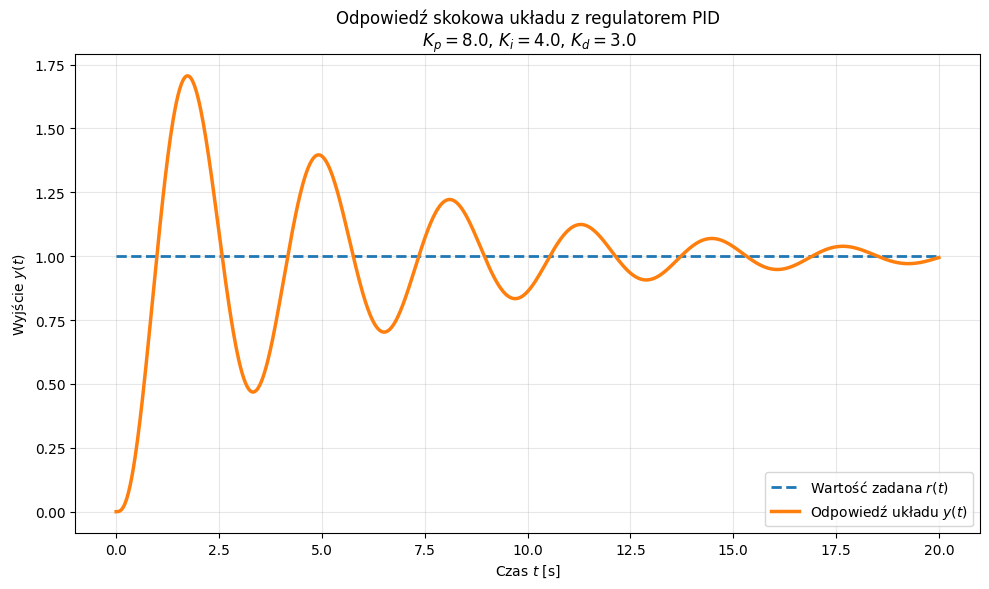

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from control import step_response

t = np.linspace(0, 20, 1000)
T, y = step_response(sys_closed, T=t)
plt.figure(figsize=(10, 6))
plt.plot(t, np.ones_like(t), '--', linewidth=2, label='Wartość zadana $  r(t)  $')
plt.plot(T, y, linewidth=2.5, label='Odpowiedź układu $  y(t)  $')
plt.xlabel('Czas $  t  $ [s]')
plt.ylabel('Wyjście $  y(t)  $')
plt.title(f'Odpowiedź skokowa układu z regulatorem PID\n $'
          f'  K_p={8.0}  $, $  K_i={4.0}  $, $  K_d={3.0}  $')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pid_odpowiedz_skokowa.png', dpi=150)
plt.show()